In [2]:
# 1) Қажетті кітапханаларды импорттаймыз
import numpy as np
from sklearn.datasets import load_digits
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 2) Digits датасетін жүктейміз
digits = load_digits()
X, y = digits.data, digits.target

print("X өлшемі:", X.shape)   # (үлгілер саны, 64 пиксель)
print("y өлшемі:", y.shape)   # (үлгілер саны,)

# 3) Train/Test-ке бөлеміз (stratify -> кластар тең бөліну үшін)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 4) Масштабтаймыз (тек train-ге fit, сосын train/test-ке transform)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train_scaled.shape)
print("Test shape :", X_test_scaled.shape)

X өлшемі: (1797, 64)
y өлшемі: (1797,)
Train shape: (1437, 64)
Test shape : (360, 64)


In [3]:
# AND логикалық есебі үшін қарапайым perceptron (from scratch)
import numpy as np

# Кіріс және мақсатты шығыс (AND)
X_and = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
], dtype=float)

y_and = np.array([0, 0, 0, 1], dtype=float)

# Персептрон параметрлері
np.random.seed(42)
w = np.random.randn(2) * 0.1   # салмақтар
b = 0.0                        # bias
lr = 0.1                       # оқу қадамы
epochs = 20

def step(z):
    """Баспалдақ (threshold) активациясы."""
    return 1.0 if z >= 0 else 0.0

# Оқыту (Perceptron learning rule)
for epoch in range(epochs):
    total_error = 0
    for x_i, y_i in zip(X_and, y_and):
        z = np.dot(x_i, w) + b
        y_pred = step(z)
        error = y_i - y_pred

        # Салмақтарды жаңарту
        w += lr * error * x_i
        b += lr * error
        total_error += abs(error)

    print(f"Epoch {epoch+1:02d} | Total error = {total_error}")

print("\nҮйренген салмақтар:", w)
print("Үйренген bias:", b)

# Нәтижені тексеру
print("\nAND болжамдары:")
for x_i in X_and:
    y_pred = step(np.dot(x_i, w) + b)
    print(f"{x_i.astype(int)} -> {int(y_pred)}")

Epoch 01 | Total error = 2.0
Epoch 02 | Total error = 3.0
Epoch 03 | Total error = 1.0
Epoch 04 | Total error = 0.0
Epoch 05 | Total error = 0.0
Epoch 06 | Total error = 0.0
Epoch 07 | Total error = 0.0
Epoch 08 | Total error = 0.0
Epoch 09 | Total error = 0.0
Epoch 10 | Total error = 0.0
Epoch 11 | Total error = 0.0
Epoch 12 | Total error = 0.0
Epoch 13 | Total error = 0.0
Epoch 14 | Total error = 0.0
Epoch 15 | Total error = 0.0
Epoch 16 | Total error = 0.0
Epoch 17 | Total error = 0.0
Epoch 18 | Total error = 0.0
Epoch 19 | Total error = 0.0
Epoch 20 | Total error = 0.0

Үйренген салмақтар: [0.14967142 0.08617357]
Үйренген bias: -0.2

AND болжамдары:
[0 0] -> 0
[0 1] -> 0
[1 0] -> 0
[1 1] -> 1


In [4]:
# XOR деректері
X_xor = np.array([
    [0, 0],
    [0, 1],
    [1, 0],
    [1, 1]
], dtype=float)

y_xor = np.array([0, 1, 1, 0], dtype=float)

# AND-та үйренген персептронды XOR-ға қолданып көрейік (немесе қайта оқытуға да болады)
print("XOR болжамдары (бір қабатты perceptron):")
for x_i in X_xor:
    y_pred = step(np.dot(x_i, w) + b)
    print(f"{x_i.astype(int)} -> {int(y_pred)}")

print("\nТүсіндірме:")
print("Бір қабатты персептрон тек бір түзу арқылы ажыратады.")
print("XOR нүктелері бір түзу арқылы ажыратылмайды (сызықтық бөлінбейді).")
print("Сондықтан бір қабатты perceptron XOR-ды толық дұрыс шеше алмайды.")

XOR болжамдары (бір қабатты perceptron):
[0 0] -> 0
[0 1] -> 0
[1 0] -> 0
[1 1] -> 1

Түсіндірме:
Бір қабатты персептрон тек бір түзу арқылы ажыратады.
XOR нүктелері бір түзу арқылы ажыратылмайды (сызықтық бөлінбейді).
Сондықтан бір қабатты perceptron XOR-ды толық дұрыс шеше алмайды.


In [5]:
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

# ReLU активациясы бар MLP
mlp_relu = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    activation='relu',
    solver='adam',
    max_iter=100,
    random_state=42
)

# Модельді оқыту
mlp_relu.fit(X_train_scaled, y_train)

# Болжам және дәлдік
y_pred_relu = mlp_relu.predict(X_test_scaled)
acc_relu = accuracy_score(y_test, y_pred_relu)

print(f"ReLU MLP test accuracy: {acc_relu:.4f}")

ReLU MLP test accuracy: 0.9639


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


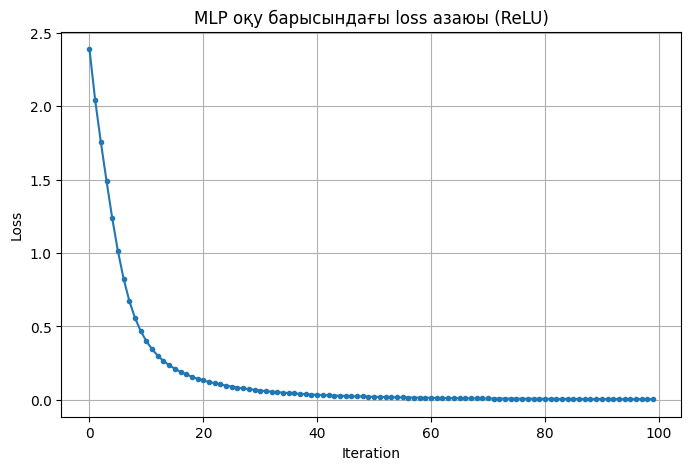

In [6]:
import matplotlib.pyplot as plt

# Мысал ретінде ReLU моделінің loss_curve_ графигі
plt.figure(figsize=(8, 5))
plt.plot(mlp_relu.loss_curve_, marker='o', markersize=3)
plt.title("MLP оқу барысындағы loss азаюы (ReLU)")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (100) reached and the optimization hasn't converged yet.
  warnings.warn(


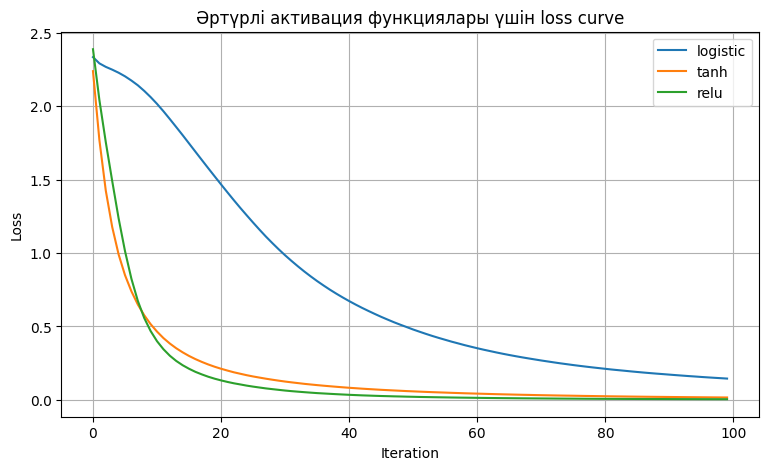

In [7]:
plt.figure(figsize=(9, 5))

for act in ['logistic', 'tanh', 'relu']:
    clf = MLPClassifier(
        hidden_layer_sizes=(64, 32),
        activation=act,
        solver='adam',
        max_iter=100,
        random_state=42
    )
    clf.fit(X_train_scaled, y_train)
    plt.plot(clf.loss_curve_, label=act)

plt.title("Әртүрлі активация функциялары үшін loss curve")
plt.xlabel("Iteration")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
plt.show()

## 1) Неге бір қабатты Персептрон тек сызықтық бөлінетін есептерді шешеді, MLP қалай еңсереді?

Бір қабатты персептрон шешім шекарасын бір гипержазықтық түрінде береді (2D-де — түзу):

$$
\mathbf{w}^\top \mathbf{x} + b = 0
$$

Сондықтан ол тек **сызықтық бөлінетін** деректерді ажырата алады.  
Мысалы, XOR есебінде нүктелерді бір ғана түзу арқылы бөлу мүмкін емес.

MLP (көпқабатты желі) бірнеше қабат пен бейсызық активацияларды қолданады:

$$
\mathbf{a}^{(l)} = f\!\left(\mathbf{W}^{(l)}\mathbf{a}^{(l-1)} + \mathbf{b}^{(l)}\right)
$$

Осылайша желі күрделі, бейсызық шешім шекараларын құрып, XOR сияқты есептерді шеше алады.

---

## 2) Forward және Backward propagation-ның математикалық рөлі

### Forward propagation
Әр қабатта алдымен сызықтық түрлендіру, сосын активация орындалады:

$$
\mathbf{z}^{(l)} = \mathbf{W}^{(l)}\mathbf{a}^{(l-1)} + \mathbf{b}^{(l)},
\qquad
\mathbf{a}^{(l)} = f\!\left(\mathbf{z}^{(l)}\right)
$$

Соңғы қабаттан болжам $\hat{\mathbf{y}}$ алынып, шығын (loss) есептеледі:

$$
\mathcal{L} = \mathcal{L}(\mathbf{y}, \hat{\mathbf{y}})
$$

### Backward propagation
Chain rule арқылы шығынның параметрлерге туындылары табылады:

$$
\frac{\partial \mathcal{L}}{\partial \mathbf{W}^{(l)}},
\qquad
\frac{\partial \mathcal{L}}{\partial \mathbf{b}^{(l)}}
$$

Содан кейін параметрлер градиенттік түсу арқылы жаңартылады:

$$
\mathbf{W}^{(l)} \leftarrow \mathbf{W}^{(l)} - \eta \frac{\partial \mathcal{L}}{\partial \mathbf{W}^{(l)}},
\qquad
\mathbf{b}^{(l)} \leftarrow \mathbf{b}^{(l)} - \eta \frac{\partial \mathcal{L}}{\partial \mathbf{b}^{(l)}}
$$

мұндағы $\eta$ — learning rate.

---

## 3) Неге ReLU жиі қолданылады (vanishing gradient тұрғысынан)?

Sigmoid функциясы:

$$
\sigma(x)=\frac{1}{1+e^{-x}}
$$

Оның туындысы:

$$
\sigma'(x)=\sigma(x)\bigl(1-\sigma(x)\bigr)
$$

Қанығу аймақтарында туынды өте кіші болады, сондықтан терең желілерде градиент әлсіреп кетеді (vanishing gradient).

ReLU функциясы:

$$
f(x)=\max(0,x)
$$

Туындысы:

$$
f'(x)=
\begin{cases}
0, & x \le 0\\
1, & x > 0
\end{cases}
$$

Оң аймақта градиенттің 1-ге тең болуы градиенттің жақсы өтуіне көмектеседі. Сондықтан оқыту көбіне жылдамырақ әрі тұрақтырақ болады.